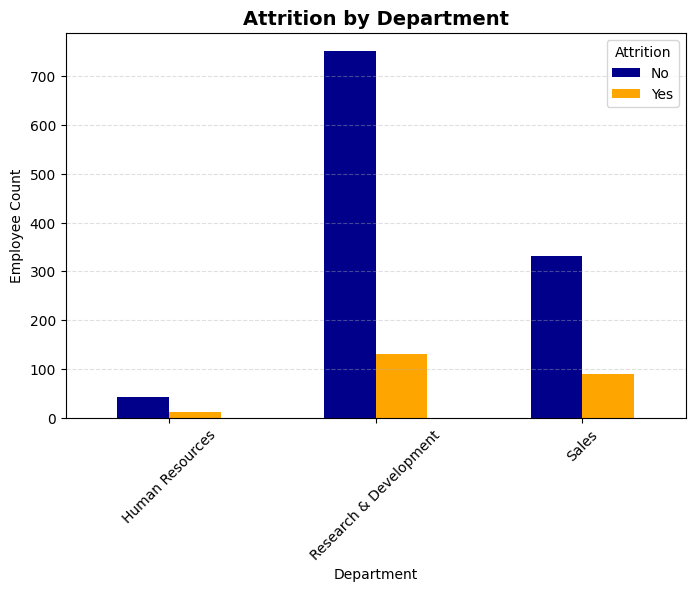

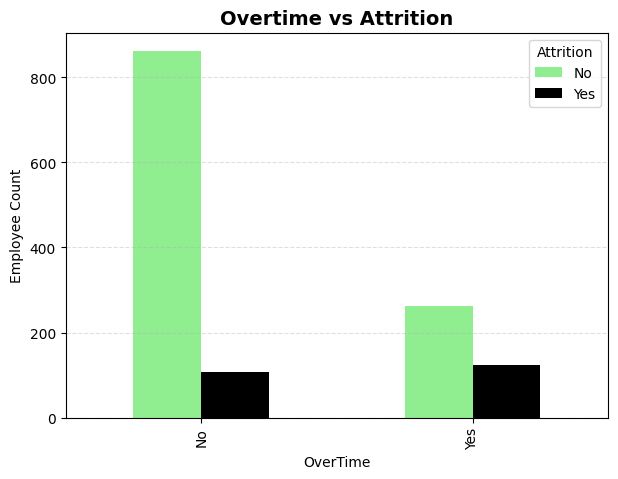

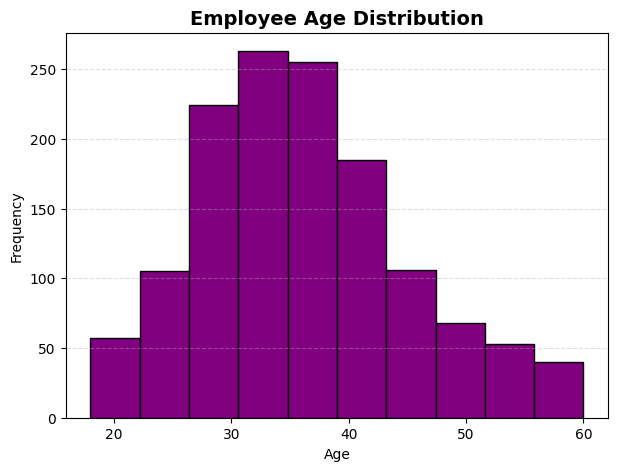

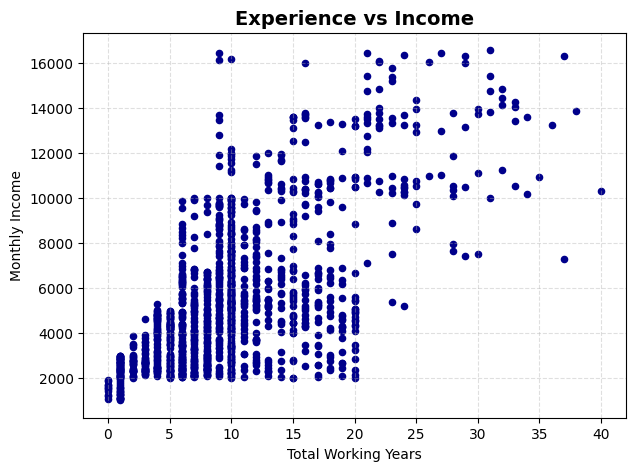

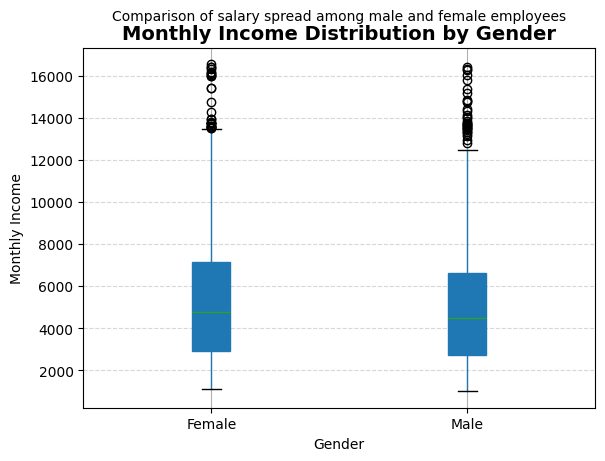

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("employee.csv")

# cleaning
df = df.fillna(df.mean(numeric_only=True))
df = df.drop_duplicates()

# remove outliers
Q1 = df["MonthlyIncome"].quantile(0.25)
Q3 = df["MonthlyIncome"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["MonthlyIncome"] >= Q1 - 1.5*IQR) &
        (df["MonthlyIncome"] <= Q3 + 1.5*IQR)]

# 1. Attrition by department
df.groupby("Department")["Attrition"].value_counts().unstack().plot(
    kind="bar",
    color=["darkblue", "orange"],
    figsize=(8,5)
)
plt.title("Attrition by Department", fontsize=14, fontweight="bold")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

# 2. Overtime impact
df.groupby("OverTime")["Attrition"].value_counts().unstack().plot(
    kind="bar",
    color=["lightgreen", "black"],
    figsize=(7,5)
)
plt.title("Overtime vs Attrition", fontsize=14, fontweight="bold")
plt.xlabel("OverTime")
plt.ylabel("Employee Count")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

# 3. Histogram
df["Age"].plot(
    kind="hist",
    bins=10,
    color="purple",
    edgecolor="black",
    figsize=(7,5)
)
plt.title("Employee Age Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

# 4. Scatter plot
df.plot.scatter(
    x="TotalWorkingYears",
    y="MonthlyIncome",
    color="darkblue",
    figsize=(7,5)
)
plt.title("Experience vs Income", fontsize=14, fontweight="bold")
plt.xlabel("Total Working Years")
plt.ylabel("Monthly Income")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# 5. Boxplot
box = df.boxplot(
    column="MonthlyIncome",
    by="Gender",
    patch_artist=True
)

colors = ["lightblue", "lightpink"]
for patch, color in zip(box.artists, colors):
    patch.set_facecolor(color)

plt.title("Monthly Income Distribution by Gender", fontsize=14, fontweight="bold")
plt.suptitle("Comparison of salary spread among male and female employees", fontsize=10)
plt.xlabel("Gender")
plt.ylabel("Monthly Income")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()